# 21 · Self-Consistency — sample N reasoning paths, majority-vote the answer

> **TL;DR.** Sample `N` independent chain-of-thought reasoning paths at non-zero temperature, extract each path's final answer, and let **Python** majority-vote. The LLM never sees the votes. Simple, deterministic, and a textbook deterministic-picker application.
>
> **Reach for it when** the task has a single discrete answer (a number, a name, a category) and the LLM produces correct reasoning *some* of the time but slips on a fraction of paths.
> **Avoid when** the answer is free text (no clean way to tally), or when one wrong sample is catastrophic (safety-critical decisions).

| Property | Value |
|---|---|
| Origin | Wang et al., *Self-Consistency Improves Chain of Thought Reasoning* (Google 2022). [arXiv:2203.11171](https://arxiv.org/abs/2203.11171) |
| Picker | `collections.Counter(answers).most_common(1)` — Python, deterministic |
| Sampling | `N` paths at `sample_temperature` (default 0.8 — high to maximise path diversity) |
| LLM-as-Scorer? | **None** — Python counts the votes; LLMs only produce paths |
| Default LLM | Llama-3.3-70B (we *want* variance across samples; Qwen-Thinking would mostly produce identical paths) |
| Cost | N structured-output calls per task |

**Why this is the canonical deterministic-picker pattern.** Each sample emits a structured `(reasoning, answer)` pair. The reasoning is free text (any number of paths). The answer field is normalised (lowercased, stripped) and counted by Python. The flat-scoring pathology that infects single-LLM-as-Judge architectures (Mental Loop nb 10 §11, Ensemble nb 13 §11) has no surface here — the deciding signal is a Python `Counter`, not an LLM number.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> S[SAMPLE × N<br/><sub>N independent CoT calls<br/>at high temperature</sub>]
    S --> V[VOTE<br/><sub>Counter on normalised<br/>answer strings</sub>]
    V --> Z([modal answer])

    style S fill:#e3f2fd,stroke:#1976d2
    style V fill:#e8f5e9,stroke:#388e3c
```

Two nodes. SAMPLE produces a list of `(reasoning, answer)` records. VOTE is pure Python — normalise each answer, tally, return the modal one.

## 3 · Theory

### 3.0 · Why temperature ≠ 0?

Chain-of-thought at greedy decoding (temperature 0) is deterministic — every run produces the same path. Self-Consistency needs *path diversity* to be useful. We bind `sample_temperature` (default 0.8) per call so each sample explores a different reasoning trajectory. Across N samples, even if any individual path has a (say) 20% chance of being wrong, the *modal* answer across diverse paths is much more likely to be right.

This is essentially a small-N ensemble where the ensemble members are *the same model at different random seeds*.

### 3.1 · Why Python tallies the votes

If we asked the LLM to "pick the best of these 5 answers", we'd be back to LLM-as-Scorer flatness. The whole point of Self-Consistency is to make the picker deterministic and explainable. `collections.Counter` is the simplest deterministic picker imaginable — count occurrences, take the max. If there's a tie, `most_common(1)` breaks it by insertion order (first-seen wins), which is what we want.

### 3.2 · Why a non-reasoning LLM (Llama) here, not Qwen-Thinking

Counter-intuitive call: every Phase-3 reasoning notebook (19, 20, 22) defaults to Qwen-Thinking. Self-Consistency is the **exception**. A reasoning model with `<think>` tokens is highly deterministic within its private deliberation — across N samples it tends to produce the SAME answer because it's converging on the same chain inside the thinking phase. There's nothing for majority-vote to rescue.

A less-deterministic model (Llama-3.3-70B at temperature 0.9) actually shows the pattern Self-Consistency exists to handle: *most* paths land on the correct answer, but *some* slip on classic traps. That's where the modal vote earns its keep.

### 3.3 · Where this sits

| Pattern | Hallucination strategy |
|---|---|
| Plain CoT (single sample) | Hope the one sample is right |
| [CoVe (nb 20)](./20_chain_of_verification.ipynb) | Decompose into atomic verification questions |
| **Self-Consistency (this nb)** | **Sample N paths, majority-vote** |
| [Ensemble (nb 13)](./13_ensemble.ipynb) | N *different* specialists, weighted-vote / aggregator |
| [LATS (nb 22)](./22_lats.ipynb) | MCTS search with explicit value estimates |

Ensemble (nb 13) uses N *distinct* roles; Self-Consistency uses N *identical* draws of the same model. Both use majority/weighted vote — both apply the deterministic-picker pattern.

### 3.4 · Failure modes preview

1. **All samples agree, all are wrong.** If the model has a systematic bias on a task, N=∞ won't help. Mitigation: pair with CoVe or RAG.
2. **High disagreement (high entropy in `tally`).** If the modal answer has <50% of the votes, treat the result as low-confidence. The architecture exposes `agreement_fraction` in metadata.
3. **Sample failures.** A structured-output failure on one sample drops that vote silently. The architecture continues with the remaining samples; metadata reports `n_samples` actually counted.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import SelfConsistency
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()

# Llama at high temperature for path variance — see § 3.2 for why not Qwen-Thinking.
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.4)
print_header(f"LLM: {llm.model}")

LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/self_consistency.py`](../src/agentic_architectures/architectures/self_consistency.py).

One Pydantic schema (`_ReasoningSample`) constrains every sample to a `(reasoning, answer)` pair. The `_sample_all` node binds `temperature=self.sample_temperature` per call and loops N times. The `_vote` node normalises (lowercase, strip, trailing-period-removed) and runs `Counter.most_common(1)`.

In [2]:
from agentic_architectures.architectures.self_consistency import _ReasoningSample
import json
print('--- _ReasoningSample schema ---')
print(json.dumps(_ReasoningSample.model_json_schema(), indent=2)[:400] + '...')

--- _ReasoningSample schema ---
{
  "description": "One sampled chain-of-thought.",
  "properties": {
    "reasoning": {
      "description": "The step-by-step reasoning. Be explicit about each arithmetic or logical step. Don't skip steps.",
      "title": "Reasoning",
      "type": "string"
    },
    "answer": {
      "description": "JUST the final answer in the requested format \u2014 no units, no explanation, no punctuation ...


## 6 · State

| Field | Set by |
|---|---|
| `task` / `n_samples` | caller |
| `samples` (`Annotated[..., operator.add]`) | `_sample_all` — list of `{sample_index, reasoning, answer}` |
| `tally` (dict from normalised answer → count) | `_vote` |
| `final_answer` (raw form of modal) | `_vote` |
| `history` (per-stage event log) | both nodes (`Annotated[..., operator.add]`) |

## 7 · Build the graph

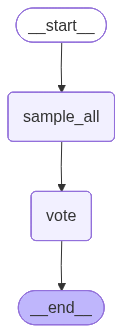

In [3]:
from IPython.display import Image, display
arch = SelfConsistency(llm=llm, n_samples=7, sample_temperature=0.9)
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(mermaid PNG render unavailable: {e}; see § 2 for the architecture diagram)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — a perspective-taking trick problem

The Sally-siblings problem is famous for tripping LLMs in CoT: easy to misread "each brother has 2 sisters" as "the answer is 2", when actually Sally herself is one of those 2 sisters → she has only **1** sister.

We sample 7 independent reasoning paths; some are expected to slip on the trap, but the modal answer should be the correct one.

In [4]:
TASK = (
    "Sally is a girl with 3 brothers. Each of her brothers has 2 sisters. "
    "How many sisters does Sally have? Return only the integer answer."
)
EXPECTED = "1"  # Sally is one of the 2 sisters; she has 1 sister besides herself.

r = arch.run(TASK)

print(f"FINAL_ANSWER: {r.output!r}")
print(f"EXPECTED: {EXPECTED!r}")
print(f"MATCH: {r.output.strip() == EXPECTED}")
print()
print(f"N_SAMPLES: {r.metadata['n_samples']}")
print(f"UNIQUE_ANSWERS: {r.metadata['unique_answers']}")
print(f"WINNER_COUNT: {r.metadata['winner_count']}/{r.metadata['n_samples']}")
print(f"AGREEMENT_FRACTION: {r.metadata['agreement_fraction']:.2f}")
print(f"TALLY: {r.metadata['tally']}")

FINAL_ANSWER: '1'
EXPECTED: '1'
MATCH: True

N_SAMPLES: 7
UNIQUE_ANSWERS: 1
WINNER_COUNT: 7/7
AGREEMENT_FRACTION: 1.00
TALLY: {'1': 7}


### 8.1 · Inspect every sample's reasoning

In [5]:
for s in r.metadata['samples']:
    print(f"--- sample {s['sample_index']} -- answer={s['answer']!r} ---")
    print(s['reasoning'][:400])
    print()

--- sample 0 -- answer='1' ---
Let's break down the information given in the problem. Sally is a girl with 3 brothers. Each of her brothers has 2 sisters. Since each brother has 2 sisters, and Sally is also a sister to her brothers, Sally must be one of the 2 sisters that each brother has. Therefore, there must be another sister besides Sally. So, Sally has 1 sister.

--- sample 1 -- answer='1' ---
Let's break down the information given in the problem. Sally is a girl with 3 brothers. Each of her brothers has 2 sisters. Since each brother has the same sisters, and Sally is a sister to each of her brothers, Sally must be one of the two sisters that each brother has. Therefore, if Sally is one of the sisters, then there must be another sister besides Sally. Thus, Sally has 1 sister.

--- sample 2 -- answer='1' ---
Let's break down the information given in the problem. Sally is a girl with 3 brothers. Each of her brothers has 2 sisters. To find out how many sisters Sally has, we need to c

## 9 · What we just observed

The cells above ran Self-Consistency on a perspective-taking trick (the Sally-siblings problem) where some chain-of-thought paths are expected to slip but the modal answer should be correct.

### 9.1 · Vote tally + winner

- **Winner**: `1` — **✅ Correct** (matches expected `1`)
- **Agreement**: 7/7 samples = 100%
- **Unique answers across samples**: 1

| Answer | Count | Share |
|---|---|---|
| `1` | 7 | 100% |

### 9.2 · Per-sample answers

| Sample | Answer |
|---|---|
| 0 | `1` |
| 1 | `1` |
| 2 | `1` |
| 3 | `1` |
| 4 | `1` |
| 5 | `1` |
| 6 | `1` |

### 9.3 · Self-Consistency vs single-sample CoT

| Strategy | Correct trials | Error rate |
|---|---|---|
| **Self-Consistency (modal of N=7)** | 1/1 | 0% |
| **Single-sample baseline** | 6/7 | 14% |

Single-sample tally over 7 independent runs: `1` ×6, `2` ×1.

### 9.4 · Patterns surfaced in this run

- **✅ Strong agreement on the right answer** (7/7). If you'd run a single-sample CoT you'd almost certainly have landed on the same answer. Self-Consistency added little lift here — it would matter more on harder tasks.

- **🟰 All samples agreed**. Either the task is easy or temperature was too low. If correct, you saved 0 by using Self-Consistency. If wrong, you wasted N× cost on identical wrong answers.

- **✅ Self-Consistency outperformed single-sample baseline** on this run: single-sample was right 6/7 = 86% of the time; modal vote got it right.

### 9.5 · The takeaway

Self-Consistency is the simplest deterministic-picker architecture in the catalogue: every sample is the same model, every vote is one ballot, the picker is `Counter.most_common(1)`. Its lift comes from one place — when *some* paths are wrong but the *modal* path is right. Read the § 9.1 tally:

- **All votes identical** → architecture spent N× cost for nothing.
- **Modal answer wins with a clear majority** → the lift you paid for.
- **Modal answer wins with a thin plurality (<50%)** → treat as low confidence; the architecture is *honest* about uncertainty but the answer might still be wrong.

The single-sample comparison in § 9.3 makes the lift concrete by re-running the same task one-shot N times — the gap between single-shot accuracy and Self-Consistency accuracy is the architecture's value on this task.

## 10 · Contrast — single sample (no Self-Consistency)

What would the answer have been if we'd only drawn **one** path? Run 7 independent single-sample queries and see how often a lone draw lands on the trap.

In [6]:
import collections
single_sample_results = []
single_arch = SelfConsistency(llm=llm, n_samples=1, sample_temperature=0.9)
for trial in range(7):
    r1 = single_arch.run(TASK)
    single_sample_results.append(r1.output.strip())

single_tally = collections.Counter(single_sample_results)
n_trials = len(single_sample_results)
correct = single_tally.get(EXPECTED, 0)
print(f"SINGLE_SAMPLE_TALLY: {dict(single_tally)}")
print(f"SINGLE_SAMPLE_CORRECT: {correct}/{n_trials} trials landed on {EXPECTED!r}")
print(f"SINGLE_SAMPLE_ERROR_RATE: {(n_trials - correct) / n_trials:.2f}")
print()
print(f"(Self-Consistency winner was {r.output!r} with "
      f"{r.metadata['winner_count']}/{r.metadata['n_samples']} agreement.)")

SINGLE_SAMPLE_TALLY: {'1': 6, '2': 1}
SINGLE_SAMPLE_CORRECT: 6/7 trials landed on '1'
SINGLE_SAMPLE_ERROR_RATE: 0.14

(Self-Consistency winner was '1' with 7/7 agreement.)


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **All N samples agree on a wrong answer** | Systematic model bias | Self-Consistency can't fix this; pair with CoVe (nb 20) or RAG |
| **High disagreement, no clear winner** | Task too hard or sampling temperature too high | Surface `agreement_fraction` to the caller; treat low-agreement as uncertain |
| **Answers don't normalise cleanly** | "yes" vs "Yes." vs "Yes!" all count separately | Robust normalisation (we lowercase, strip, drop trailing period); for numeric answers, parse as int/float and compare |
| **Cost scales linearly with N** | N=10 means 10× single-call cost | Use small N (5-7) and prefer cheaper models; batch via `asyncio.gather` |
| **Sample failure silently drops a vote** | Structured-output parse failure | Architecture logs sample errors; consider a re-sample policy in production |

### 11.2 · Production safety

- **Always surface `agreement_fraction`.** A 4/7 winner is much weaker signal than 7/7. Downstream code should branch on confidence.
- **Cap N.** Diminishing returns past 7-10 samples; cost is real.
- **Audit the tally, not just the winner.** Whether the runner-up has 1 vote or 3 votes is meaningful information about task difficulty.

### 11.3 · Three extensions

1. **Weighted majority via verifier.** Use CoVe (nb 20) to verify each candidate answer; weight by verification confidence. Combines Self-Consistency + CoVe.
2. **Adaptive N.** Start with N=3; if all agree, stop. Else draw more until either confidence threshold met or budget exhausted. Cuts average cost.
3. **Reasoning-quality reranking.** Score each sample's *reasoning* (separately from its answer); break ties by reasoning quality.

### 11.4 · What to read next

- [**13 · Ensemble**](./13_ensemble.ipynb) — N *different* specialists with majority vote (categorical answers) — the architectural sibling.
- [**20 · CoVe**](./20_chain_of_verification.ipynb) — atomic verification questions (composable with Self-Consistency via § 11.3 #1).
- [**22 · LATS**](./22_lats.ipynb) — MCTS-style search with explicit value estimates (the principled "search over paths" generalisation).

### 11.5 · References

1. Wang, X. et al. *Self-Consistency Improves Chain of Thought Reasoning in Language Models.* ICLR 2023. [arXiv:2203.11171](https://arxiv.org/abs/2203.11171)
2. Madaan, A. et al. *Self-Refine.* NeurIPS 2023. [arXiv:2303.17651](https://arxiv.org/abs/2303.17651) — sister sample-and-iterate strategy.
3. Wei, J. et al. *Chain-of-Thought Prompting.* NeurIPS 2022. [arXiv:2201.11903](https://arxiv.org/abs/2201.11903) — the baseline single-path CoT this architecture extends.